# Swiggy Data Analysis Project

## Project Overview:
This project analyzes Swiggy sales data to understand revenue trends, customer preferences, restaurant performance, and category performance using Python.

## Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

## Key Analysis Performed:
- Total Revenue
- Total Orders
- Average Rating
- Average Order Value
- Total Restaurants
- Top 10 Cities by Revenue
- Top 10 Restaurants by Revenue
- Top categories by Revenue
- Monthly Revenue Trend
- Highest Rated Restaurants
- Most Reviewed Restaurants
- State-wise Revenue
- Category-wise Average Rating
- Top Dishes by Revenue
- Orders by Day of Week
- Orders by Month

## Key Insights:
- Bengaluru generated the highest revenue among all cities.
- KFC was the top revenue-generating restaurant.
- Recommended and Main Course were the highest-performing categories.
- Monthly revenue remained stable throughout the period.
- Saturday recorded the highest number of orders.
- Multiple categories achieved excellent customer ratings.



In [1]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# UPLOAD DATASET
from google.colab import files
uploaded = files.upload()

Saving swiggy_data.xlsx to swiggy_data.xlsx


In [3]:
# LOAD DATASET
df = pd.read_excel("swiggy_data.xlsx")

df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
# CHECKING LAST RECORDS OF DATASET
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [5]:
# CHECKING TOTAL NUMBER OF ROWS
print("No. of Rows:", df.shape[0])

No. of Rows: 197430


In [6]:
# CHECKING TOTAL NUMBER OF COLUMNS
print("No. of Columns:", df.shape[1])

No. of Columns: 10


In [7]:
# OVERVIEW OF DATASET STRUCTURE AND DATA TYPES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [8]:
# STATISTICAL SUMMARY OF NUMERICAL COLUMNS
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [9]:
# CHECKING MISSING VALUES
df.isnull().sum()




,0
State,0
City,0
Order Date,0
Restaurant Name,0
Location,0
Category,0
Dish Name,0
Price (INR),0
Rating,0
Rating Count,0


In [10]:
# CHECKING AND HANDLE DUPLICATE VALUES
df = df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [11]:
# FEATURE ENGINEERING
df["Month"] = df["Order Date"].dt.month_name()
df["Year"] = df["Order Date"].dt.year
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter


df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count,Month,Year,Day,Quarter
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,June,2025,Sunday,2
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,April,2025,Thursday,2
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,January,2025,Wednesday,1
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,April,2025,Thursday,2
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,March,2025,Thursday,1


In [12]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count,Year,Quarter
count,197403,197403.000000,197403.000000,197403.000000,197403.0,197403.000000
mean,2025-05-01 19:42:28.028145152,268.501413,4.341579,28.323637,2025.0,1.883882
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000,2025.0,1.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000,2025.0,1.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000,2025.0,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000,2025.0,3.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000,2025.0,3.000000
std,NaN,219.222980,0.422585,87.547541,0.0,0.781580


In [13]:
# TOTAL REVENUE
total_rev = df["Price (INR)"].sum()
print("Total Revenue:", round(total_rev))

Total Revenue: 53002984


In [14]:
# TOTAL ORDERS
total_orders = len(df)
print("Total Orders:", total_orders)

Total Orders: 197403


In [15]:
# AVERAGE RATING
average_rating = df["Rating"].mean()
print("Avearage Rating:", round(average_rating,1))

Avearage Rating: 4.3


In [16]:
# AVERAGE ORDER VALUE
average_order_value = df["Price (INR)"].mean()
print("Average Order Value:", round(average_order_value,2))


Average Order Value: 268.5


In [17]:
# TOTAL RESTAURANTS
total_restaurants = df["Restaurant Name"].nunique()
print("Total Restaurants:", total_restaurants)


Total Restaurants: 993


City
Bengaluru     5455887.73
Lucknow       3117359.65
Hyderabad     3021711.62
Mumbai        3015573.35
New Delhi     2829180.60
Ahmedabad     2815536.27
Chandigarh    2804991.82
Kolkata       2662213.76
Chennai       2642594.63
Jaipur        2502833.61
Name: Price (INR), dtype: float64


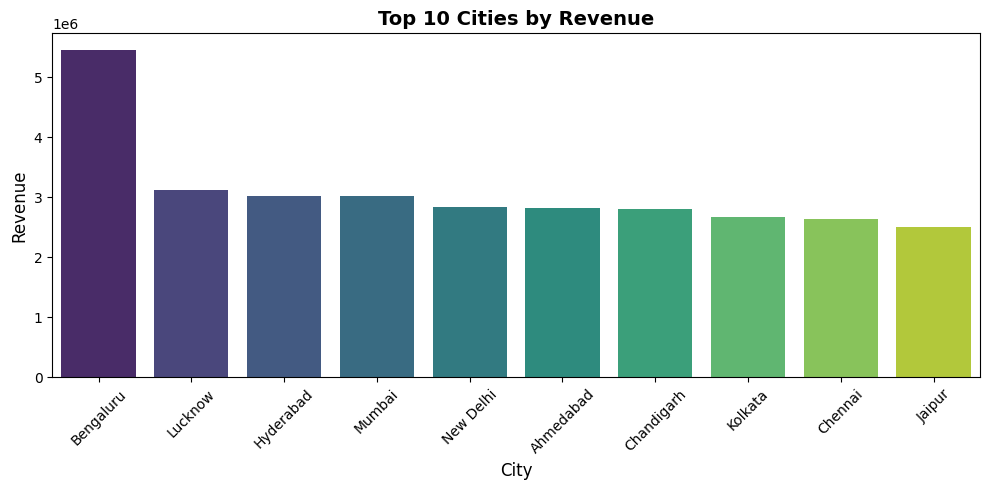

In [18]:
# TOP 10 CITIES BY REVENUE
city_rev = df.groupby("City")["Price (INR)"].sum().sort_values(ascending=False).head(10)
print(city_rev)

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_rev.index,
    y=city_rev.values,
    palette="viridis"
)

plt.title("Top 10 Cities by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Insight:**
Bengaluru was the top revenue-generating city, while Lucknow and Hyderabad also showed strong sales performance.

Restaurant Name
KFC                                    4245461.78
McDonald's                             3342455.58
Pizza Hut                              2133265.69
Burger King                            1900518.09
Domino's Pizza                         1832985.32
Olio - The Wood Fired Pizzeria         1232731.00
LunchBox - Meals and Thalis            1101141.00
Baskin Robbins - Ice Cream Desserts     860591.94
Faasos - Wraps, Rolls & Shawarma        780215.00
The Good Bowl                           673343.00
Name: Price (INR), dtype: float64


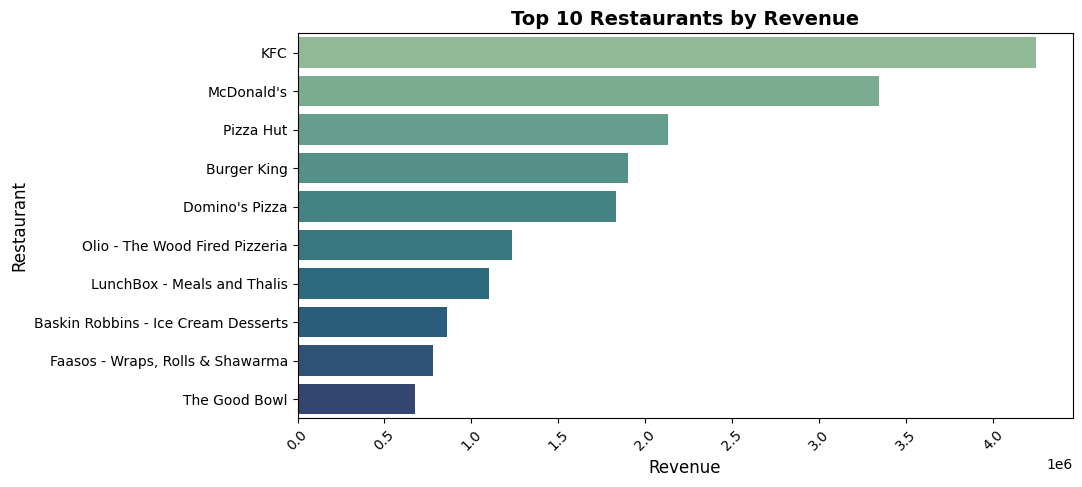

In [19]:
# TOP 10 RESTAURANTS BY REVENUE
restaurant_rev = df.groupby("Restaurant Name")["Price (INR)"].sum().sort_values(ascending=False).head(10)
print(restaurant_rev)

plt.figure(figsize=(10,5))

sns.barplot(
    x=restaurant_rev.values,
    y=restaurant_rev.index,
    palette="crest"
)

plt.title("Top 10 Restaurants by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Restaurant", fontsize=12)

plt.xticks(rotation=45)
plt.show()

**Insight:**
KFC was the top-performing restaurants by revenue, while McDonald's and Pizza Hut were also among the leading contributors.

Category
Recommended                             7188272.53
Main Course                              760045.00
Burger Combos ( 3 Pc Meals )             507773.55
McSaver Combos (2 Pc Meals)              431336.65
Desserts                                 416172.28
Korean Spicy Fest(Limited Time Only)     404892.00
Starters                                 398756.00
Freshly Scooped Tubs                     394286.00
Sweets                                   387800.40
Exclusive Deals (Save upto 40%)          383369.28
Name: Price (INR), dtype: float64


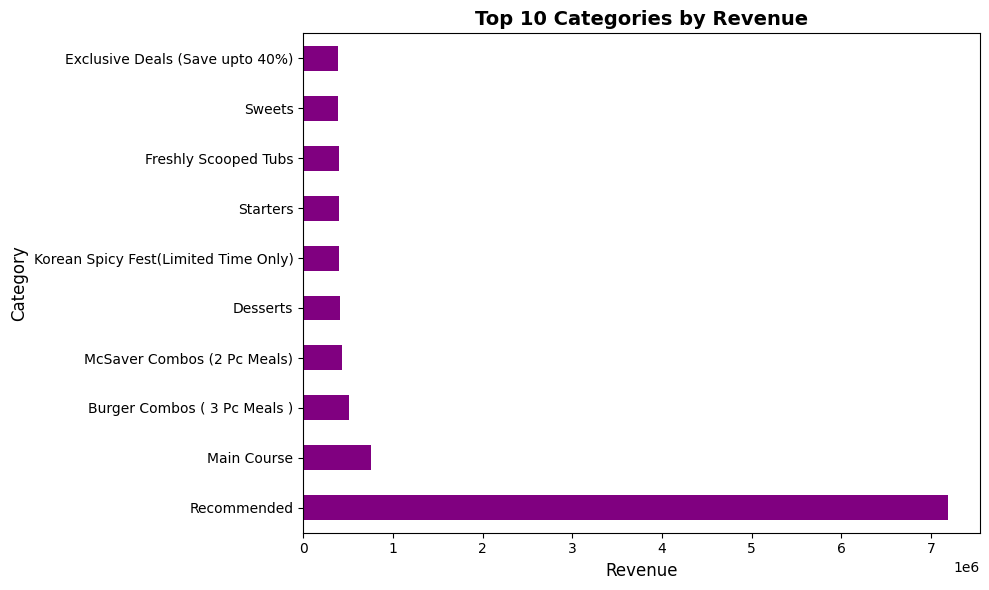

In [20]:
# TOP 10 CATEGORIES BY REVENUE
category_rev = df.groupby("Category")["Price (INR)"].sum().sort_values(ascending=False).head(10)
print(category_rev)

plt.figure(figsize=(10,6))

category_rev.plot(
    kind="barh",
    color="purple"
)

plt.title("Top 10 Categories by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.tight_layout()

plt.show()

**Insight:**
Recommended and Main Course were the top-performing categories, indicating that customers preferred complete meal options over individual items.

      Month  Price (INR)
0     April   6590449.00
1    August   6790899.22
2  February   6268161.67
3   January   6823981.33
4      July   6650268.51
5      June   6513865.19
6     March   6572738.20
7       May   6792621.35


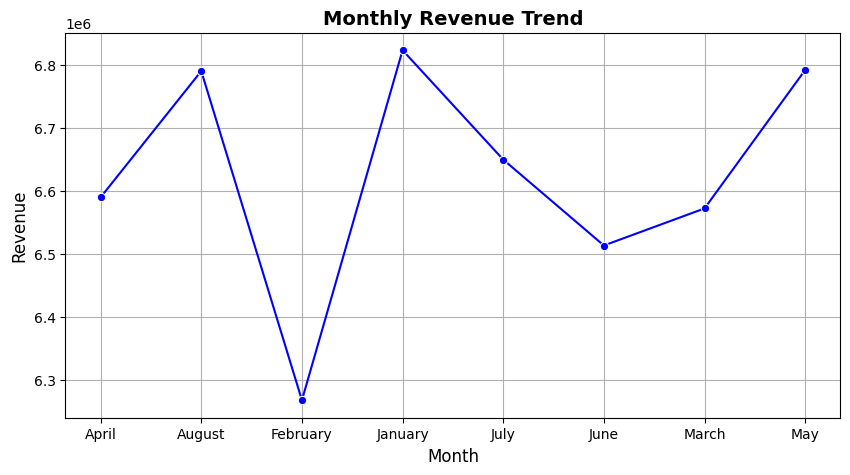

In [21]:
# MONTHLY REVENUE TREND
monthly_sales = df.groupby("Month")["Price (INR)"].sum().reset_index()
print(monthly_sales)


plt.figure(figsize=(10,5))

sns.lineplot(
    x="Month",
    y="Price (INR)",
    data=monthly_sales,
    marker="o",
    color="blue"
    )

plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.grid(True)
plt.show()


**Insight:**
Monthly Revenue showed a consistent trend across the months, with peaks in January and May and slightly lower performance in February.

Restaurant Name
Sakana                                    4.815789
Vijay Dairy                               4.750000
Jagannath Mandir Arna Prasad              4.750000
Radhey Lal's Parampara Sweets             4.736905
I Deli Cafe                               4.736170
Yadav Doodh Dairy                         4.728571
Tossin Pizza                              4.707595
Perambur Sri Srinivasa Sweets & Snacks    4.705000
Wooden Plate                              4.692453
Natural Ice Cream                         4.683908
Name: Rating, dtype: float64


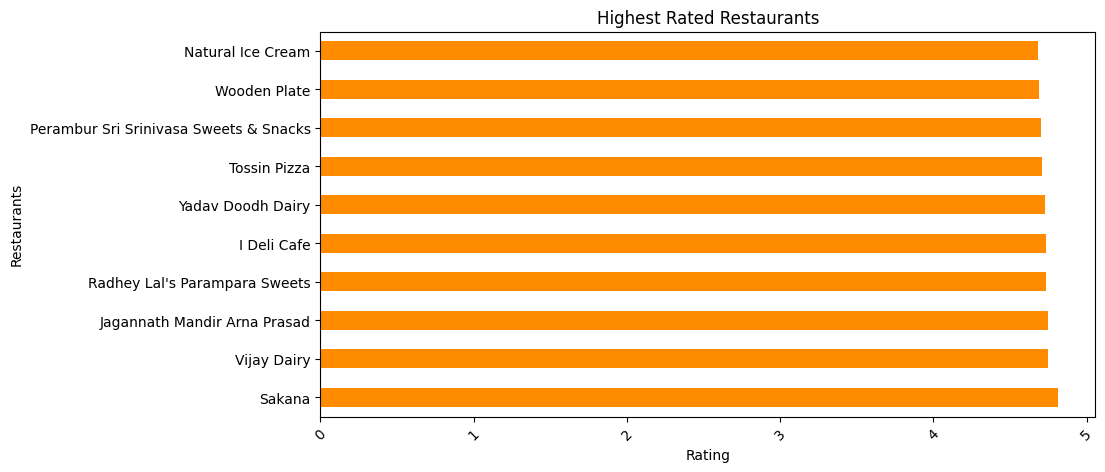

In [22]:
# HIGHEST RATED RESTAURANTS
top_rated = df.groupby("Restaurant Name")["Rating"].mean().sort_values(ascending=False).head(10)
print(top_rated)

plt.figure(figsize=(10,5))

top_rated.plot(
    kind="barh",
    color="darkorange"
)

plt.title("Highest Rated Restaurants")
plt.xlabel("Rating")
plt.ylabel("Restaurants")

plt.xticks(rotation=45)
plt.show()



**Insight:**
Sakana received the highest average rating, while Vijay Diary and Jagannath Mandir Anna Prasad also maintained excellent customer ratings.

Restaurant Name
McDonald's                     504764
KFC                            450349
Burger King                    247004
Pizza Hut                      214558
Domino's Pizza                 130933
NIC Ice Creams                  73102
LunchBox - Meals and Thalis     68583
Sangeetha Veg Restaurant        55620
Burger Farm                     51857
Jugaad Jn                       48473
Name: Rating Count, dtype: int64


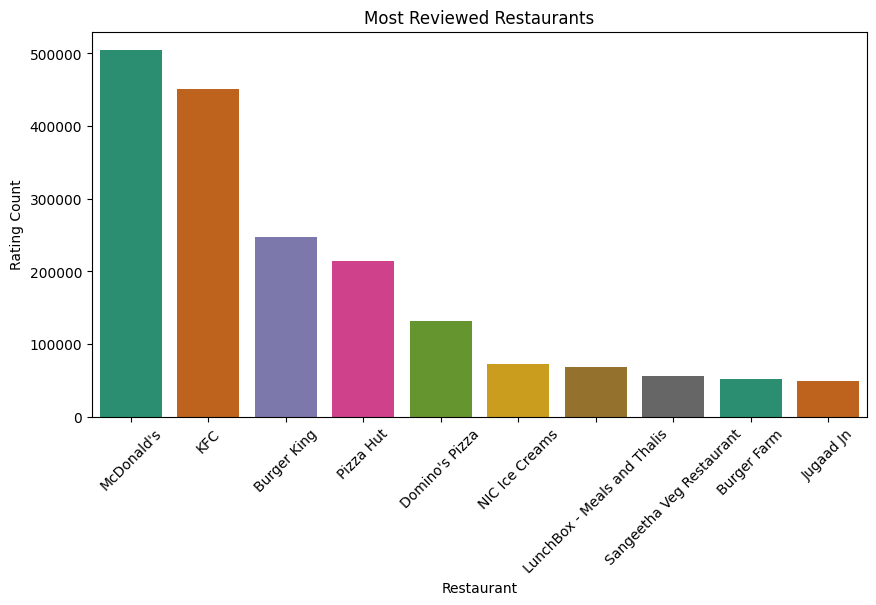

In [23]:
# MOST REVIEWED RESTAURANTS
most_reviewed = df.groupby("Restaurant Name")["Rating Count"].sum().sort_values(ascending=False).head(10)
print(most_reviewed)

plt.figure(figsize=(10,5))

sns.barplot(
    x=most_reviewed.index,
    y=most_reviewed.values,
    palette="Dark2"
)

plt.title("Most Reviewed Restaurants")
plt.xlabel("Restaurant")
plt.ylabel("Rating Count")

plt.xticks(rotation=45)
plt.show()

**Insight:**
McDonald's received the highest number of customer reviews, followed by KFC and Burger King, indicating strong customer engagement and popularity among fast-food brands.

State
Karnataka        5455887.73
Uttar Pradesh    3117359.65
Telangana        3021711.62
Maharashtra      3015573.35
Delhi            2829180.60
Gujarat          2815536.27
Punjab           2804991.82
West Bengal      2662213.76
Tamil Nadu       2642594.63
Rajasthan        2502833.61
Name: Price (INR), dtype: float64


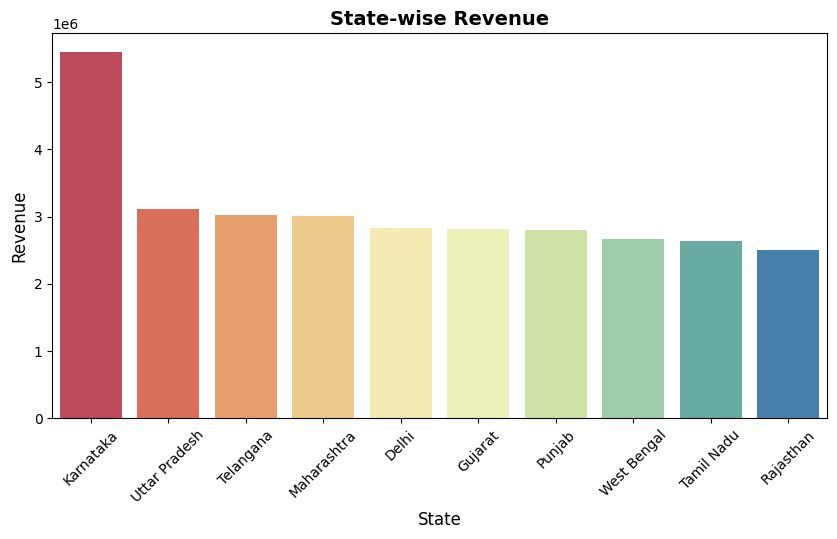

In [24]:
# STATE-WISE REVENUE
state_rev = df.groupby("State")["Price (INR)"].sum().sort_values(ascending=False).head(10)
print(state_rev)

plt.figure(figsize=(10,5))

sns.barplot(
    x=state_rev.index,
    y=state_rev.values,
    palette="Spectral"
)

plt.title("State-wise Revenue", fontsize=14, fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)
plt.show()

**Insight:**
Karnataka generated the highest revenue among all states, followed by Uttar Pradesh and Telangana, highlighting strong customer demand and sales performance in these regions.

Category
Chicken thali                         5.0
Christmas Specials                    5.0
Classic Tea                           5.0
Classic Milkshake                     5.0
Tandoori And Fry Non Veg              5.0
Tandoori Platter                      5.0
Egg deluxe thali                      5.0
South indian curry items (kulambu)    5.0
Strarters                             5.0
Add-ons                               5.0
Name: Rating, dtype: float64


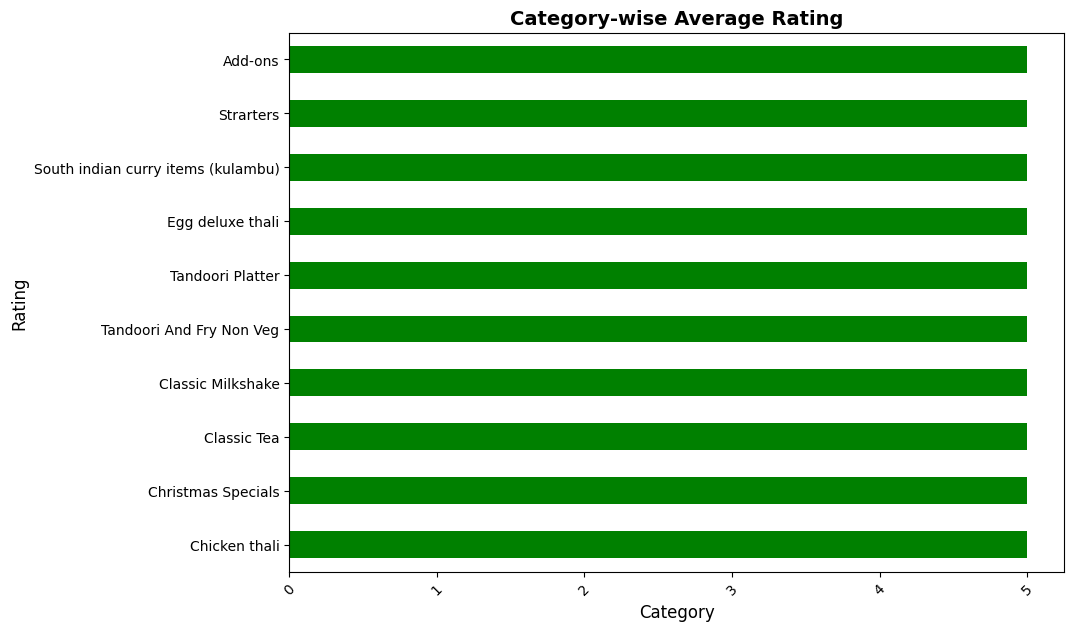

In [25]:
# CATEGORY-WISE AVERAGE RATING
category_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(10)
print(category_rating)

plt.figure(figsize=(10,7))

category_rating.plot(
    kind="barh",
    color="green"
)


plt.title("Category-wise Average Rating", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.xticks(rotation=45)
plt.show()

**Insight:**
Multiple food categories recorded a perfect average rating of 5.0, reflecting very high customer satisfaction across different cuisines and items.

Dish Name
Bold BBQ Veggie Thin n Crispy        99617.00
Korean & Thai Roll Chicken Meal      95591.57
Full House Popcorn Chicken Bucket    79200.00
Triple Chicken Feast                 70757.00
Indian Tandoori Roll Chicken Meal    70392.05
Big 12 - Chicken Bucket              69738.12
Veggie Supreme                       67841.00
Paneer Butter Masala                 67411.82
Hot & Crispy Chicken - 8 pcs         66560.85
Ultimate Savings Chicken Bucket      64611.68
Name: Price (INR), dtype: float64


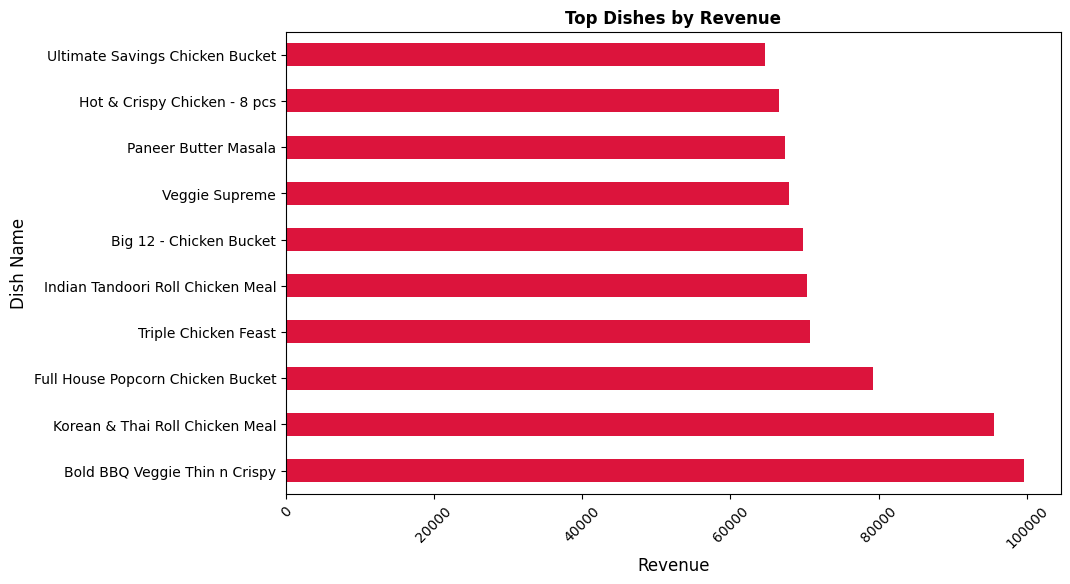

In [26]:
# TOP DISHES BY REVENUE
top_dishes = df.groupby("Dish Name")["Price (INR)"].sum().sort_values(ascending=False).head(10)
print(top_dishes)

plt.figure(figsize=(10,6))

top_dishes.plot(
    kind="barh",
    color="crimson"
)

plt.title("Top Dishes by Revenue", fontsize=12, fontweight="bold")
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Dish Name", fontsize=12)

plt.xticks(rotation=45)
plt.show()




**Insight:**
Bold BBQ Veggie Thin n Crispy was the highest revenue-generating dish, followed by Korean & Thai Roll Chicken Meal.

Day
Monday       27568
Tuesday      27413
Wednesday    28284
Thursday     28450
Friday       28285
Saturday     28933
Sunday       28470
Name: count, dtype: int64


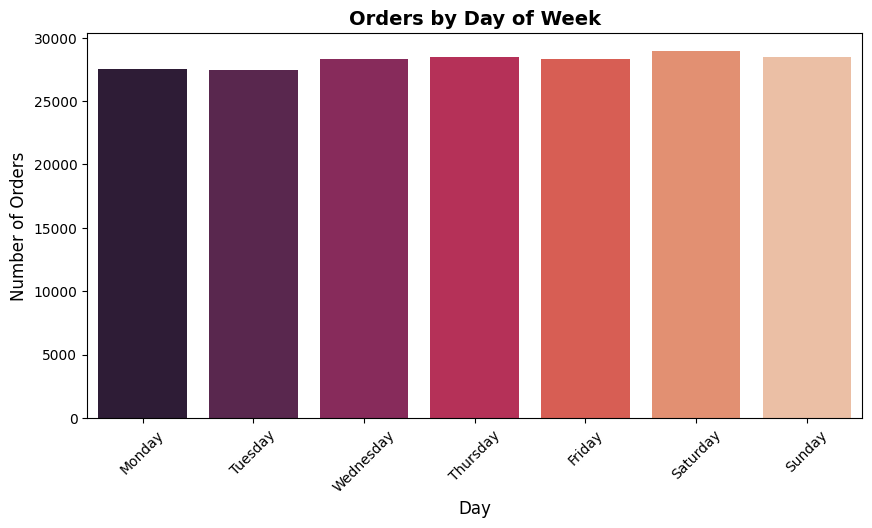

In [27]:
# ORDERS BY DAY OF WEEK
orders_day = df["Day"].value_counts().reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])
print(orders_day)

plt.figure(figsize=(10,5))

sns.barplot(
    x=orders_day.index,
    y=orders_day.values,
    palette="rocket"
)

plt.title("Orders by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=45)
plt.show()

**Insight:**
Order volume was highest on Saturday, indicating stronger customer activity during weekends, while Tuesday recorded the lowest number of orders.

Month
January     25393
February    23292
March       24400
April       24584
May         25188
June        24383
July        24936
August      25227
Name: count, dtype: int64


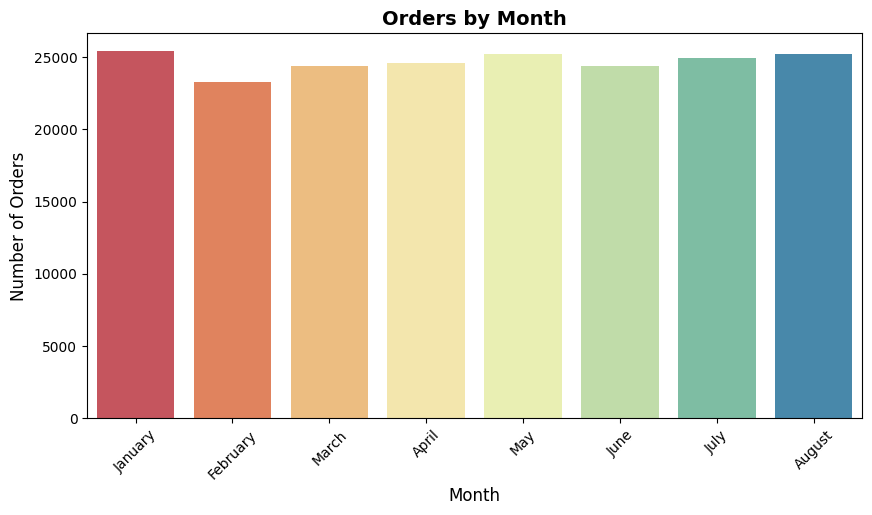

In [28]:
# ORDERS BY MONTH
orders_month = df["Month"].value_counts().reindex([
    "January", "February", "March", "April", "May", "June", "July", "August"
])
print(orders_month)

plt.figure(figsize=(10,5))

sns.barplot(
    x=orders_month.index,
    y=orders_month.values,
    palette="Spectral"
)

plt.title("Orders by Month", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=45)
plt.show()


**Insight:**
Monthly orders showed a stable trend, with January having the highest order count and February the lowest.

## Conclusion:
The Swiggy Data Analysis project provided a comprehensive understanding of sales performance, customer
behavior, and revenue trends. By analyzing cities, restaurants, categories, ratings, and order patterns, the project revealed key business insights that can help optimize growth strategies and enhance customer satisfaction.